# Demo: Soft Dynamic Time Warping (SDTW)

This notebook illustrates the usage of the SDTW loss class in the dDTW toolbox. Please refer to [1] for further details.

**References:** 

[1] Johannes Zeitler and Meinard Müller. *dDTW: A Unified and Efficient Toolbox for Differentiable Sequence Alignment*. Submitted 2026

[2] Marco Cuturi and Mathieu Blondel. *Soft-DTW: A Differentiable Loss Function for Time-Series.* In Proceedings of the International Conference on Machine Learning (ICML), 2017, pp. 894-903.

[3] Johannes Zeitler and Meinard Müller. *A Unified Perspective on CTC and SDTW using Differentiable DTW.* IEEE Transactions on Audio, Speech, and Language Processing, vol. 34, pp. 936-951, 2026.


Copyright Johannes Zeitler and Meinard Müller, 2026. 

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from ddtw import SDTW

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Selected %s device"%(device))

Selected cuda device


### Input sequences

First, we define two input sequences X and Y. X is generally considered to be a sequence of DNN predictions (therefore, it requires a gradient), while Y is a sequence of weakly aligned targets.

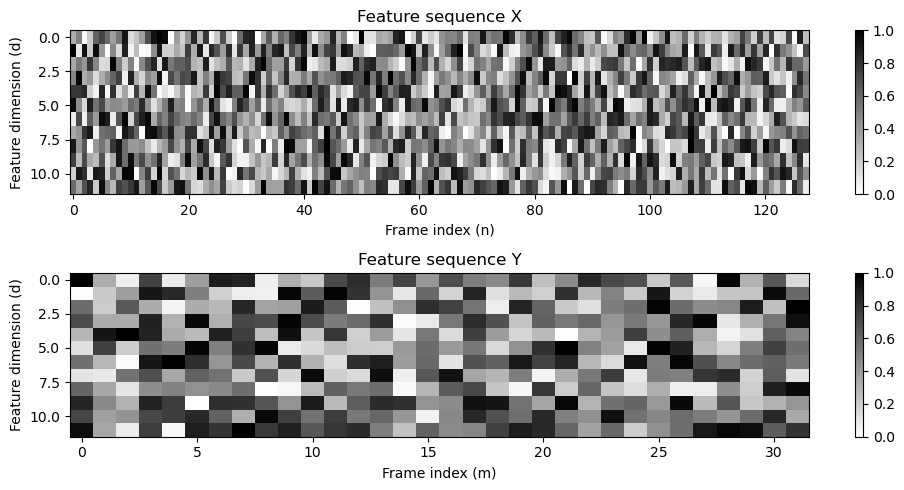

In [3]:
B = 1 # batch size
N = 128 # sequence length of X
M = 32 # sequence length of Y
D = 12 # feature dimension

X = torch.rand((B, N, D), dtype=torch.float32, device=device, requires_grad=True)
Y = torch.rand((B, M, D), dtype=torch.float32, device=device, requires_grad=False)

fig, ax = plt.subplots(2,1, figsize=(10,5))
im0 = ax[0].imshow(X[0].detach().cpu().numpy().T, aspect="auto", interpolation="None", cmap="gray_r", clim=[0,1])
im1 = ax[1].imshow(Y[0].detach().cpu().numpy().T, aspect="auto", interpolation="None", cmap="gray_r", clim=[0,1])

plt.colorbar(im0, ax=ax[0])
plt.colorbar(im1, ax=ax[1])

ax[0].set_xlabel("Frame index (n)")
ax[0].set_ylabel("Feature dimension (d)")
ax[0].set_title("Feature sequence X")


ax[1].set_xlabel("Frame index (m)")
ax[1].set_ylabel("Feature dimension (d)")
ax[1].set_title("Feature sequence Y")

fig.tight_layout()
plt.show()

### Forward and backward passes

Next, we initialize the SDTW [2] loss function. We choose the mean squared error (MSE) as a local cost function. We explicitely enable the storage of intermediate tensors that are created during loss computation, and perform a forward and backward pass. 

Via the ``.core`` attribute of the loss function class, we can access and inspect the intermediate tensors. See [3] for a detailed explanation of these matrices.
- ``core.C_matrix`` is the pair-wise cost matrix that is initially computed between X and Y
- ``core.D_matrix`` is the accumulated cost matrix that is computed during the dynamic programming forward pass
- ``core.E_matrix`` is the soft alignment matrix that is computed during the dynamic programming backward pass. It indicates the probability distribution over alignment paths.
- ``core.H_matrix`` is the gradient of the SDTW cost w.r.t. the pair-wise cost matrix C. In case of equal step weights, it is identical to E.

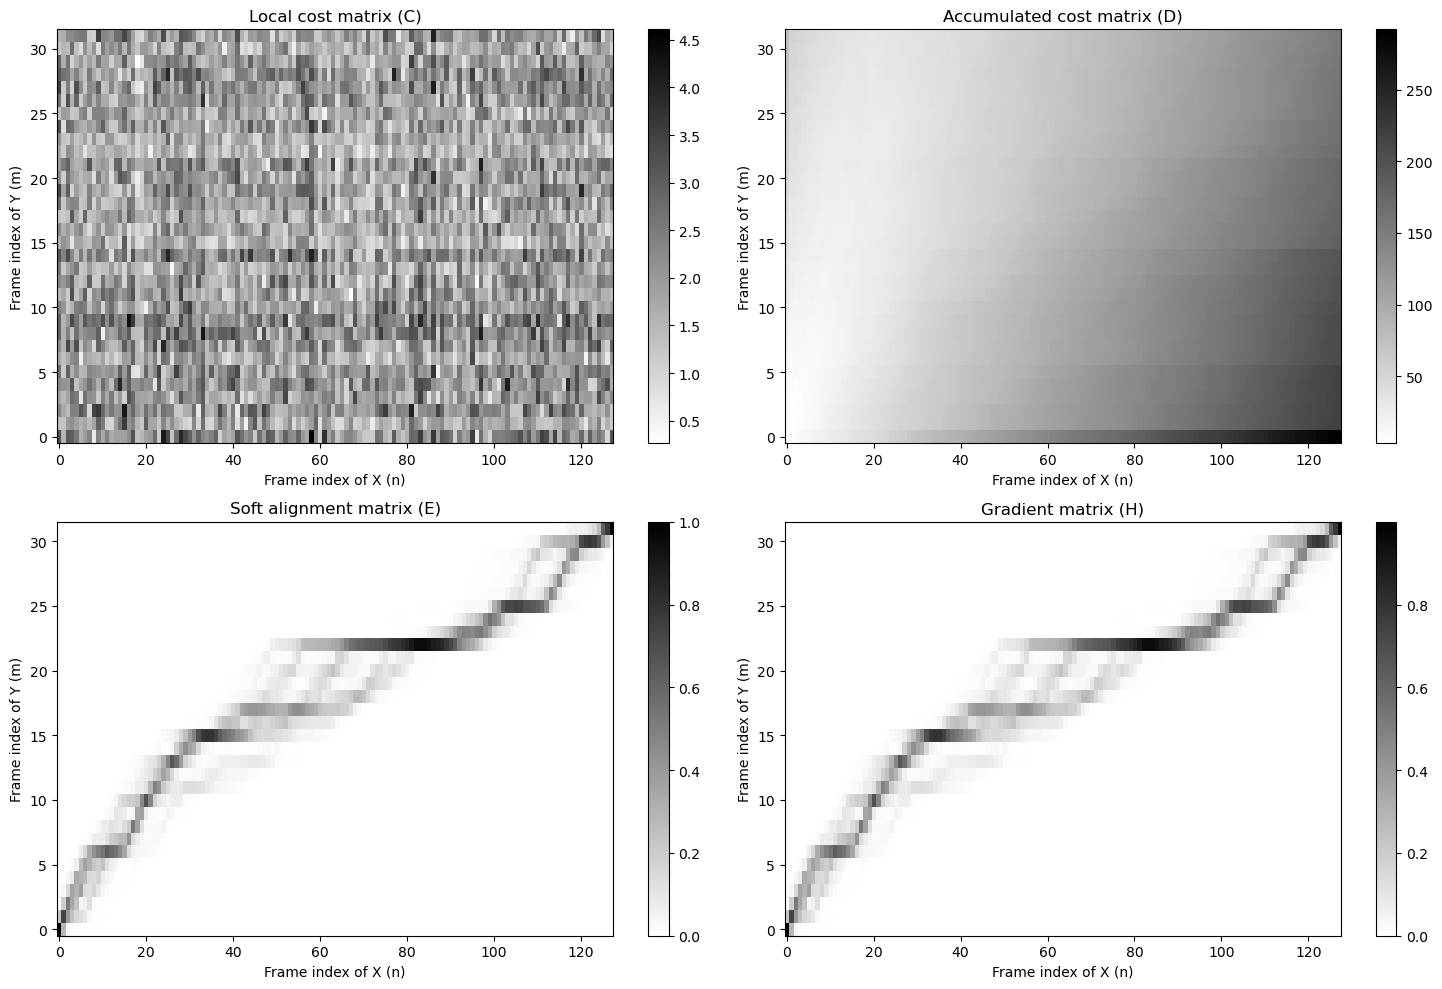

In [4]:
loss_fn = SDTW(cost_function="MSE",
               backend="auto",
               store_debug=True,
               cuda_device=device)

loss = loss_fn(X, Y)
loss.backward()
fig, ax = plt.subplots(2, 2, figsize=(15,10))

# local cost matrix
im00 = ax[0,0].imshow(loss_fn.core.C_matrix[0].detach().cpu().numpy().T, 
               aspect="auto", origin="lower", cmap="gray_r", interpolation="None")
ax[0,0].set_title("Local cost matrix (C)")
ax[0,0].set_xlabel("Frame index of X (n)")
ax[0,0].set_ylabel("Frame index of Y (m)")
plt.colorbar(im00, ax=ax[0,0])

# accumulated cost matrix
im01 = ax[0,1].imshow(loss_fn.core.D_matrix[0].detach().cpu().numpy().T, 
               aspect="auto", origin="lower", cmap="gray_r", interpolation="None")
ax[0,1].set_title("Accumulated cost matrix (D)")
ax[0,1].set_xlabel("Frame index of X (n)")
ax[0,1].set_ylabel("Frame index of Y (m)")
plt.colorbar(im01, ax=ax[0,1])

# soft alignment matrix (E)
im10 = ax[1,0].imshow(loss_fn.core.E_matrix[0].detach().cpu().numpy().T, 
               aspect="auto", origin="lower", cmap="gray_r", interpolation="None")
ax[1,0].set_title("Soft alignment matrix (E)")
ax[1,0].set_xlabel("Frame index of X (n)")
ax[1,0].set_ylabel("Frame index of Y (m)")
plt.colorbar(im10, ax=ax[1,0])

# gradient matrix (H)
im11 = ax[1,1].imshow(loss_fn.core.H_matrix[0].detach().cpu().numpy().T, 
               aspect="auto", origin="lower", cmap="gray_r", interpolation="None")
ax[1,1].set_title("Gradient matrix (H)")
ax[1,1].set_xlabel("Frame index of X (n)")
ax[1,1].set_ylabel("Frame index of Y (m)")
plt.colorbar(im11, ax=ax[1,1])

fig.tight_layout()
plt.show()

### Investigate different softmin temperatures
The softmin temperature gamma controls the smoothness of the approximation [2]. For gamma -> 0, the softmin function approximates the hard minimum. For gamma -> infinity, the gradient of the softmin function becomes a uniform distribution over its inputs. In the following, we visualize soft alignment matrices for different values of gamma.

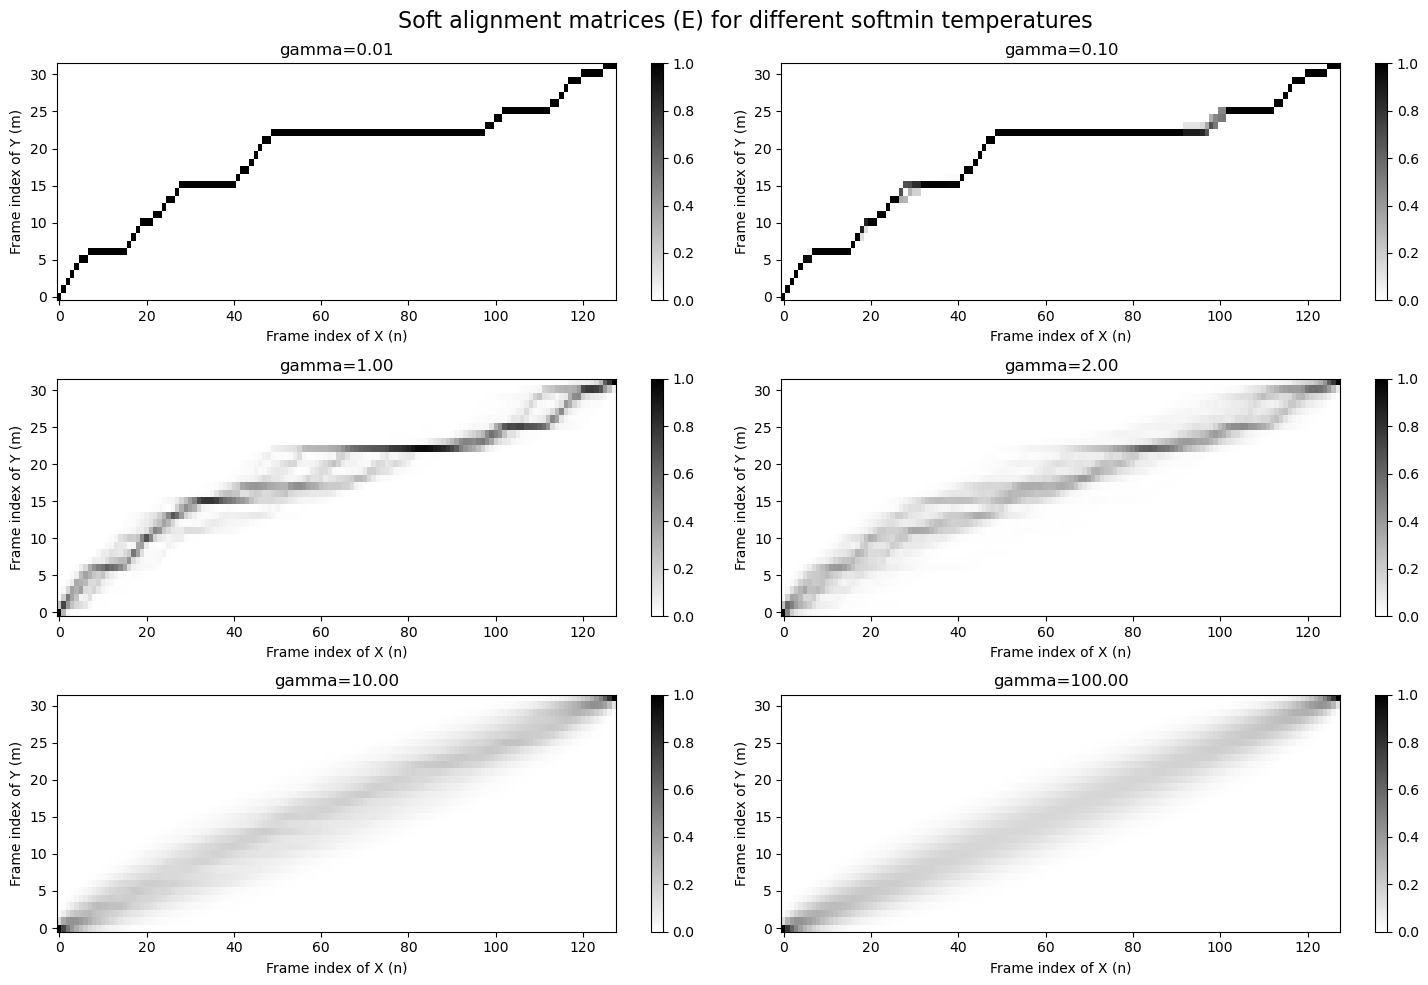

In [5]:
gammas = [0.01, 0.1, 1., 2., 10., 100]

fig, ax = plt.subplots(3,2, figsize=(15,10))

for i, gamma in enumerate(gammas):
    loss_fn = SDTW(cost_function="MSE",
                   gamma=gamma,
                   backend="auto",
                   store_debug=True)

    loss = loss_fn(X, Y)
    loss.backward()

    im = ax.flatten()[i].imshow(loss_fn.core.E_matrix[0].detach().cpu().numpy().T, 
               aspect="auto", origin="lower", cmap="gray_r", interpolation="None")
    ax.flatten()[i].set_title("gamma=%.2f"%(gamma))
    ax.flatten()[i].set_xlabel("Frame index of X (n)")
    ax.flatten()[i].set_ylabel("Frame index of Y (m)")
    plt.colorbar(im, ax=ax.flatten()[i])

fig.suptitle("Soft alignment matrices (E) for different softmin temperatures", fontsize=16)
fig.tight_layout()
plt.show()